In [3]:
import pandas as pd
dataset = pd.read_csv('heart.csv')

X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


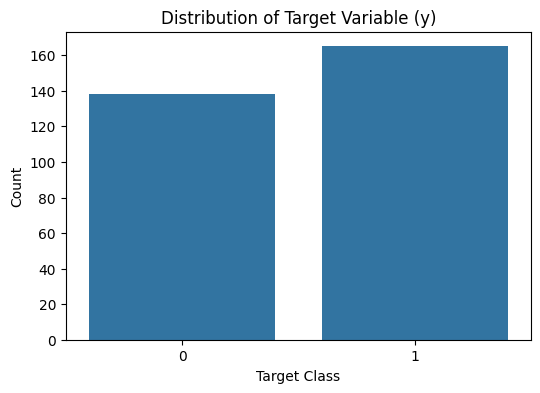

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

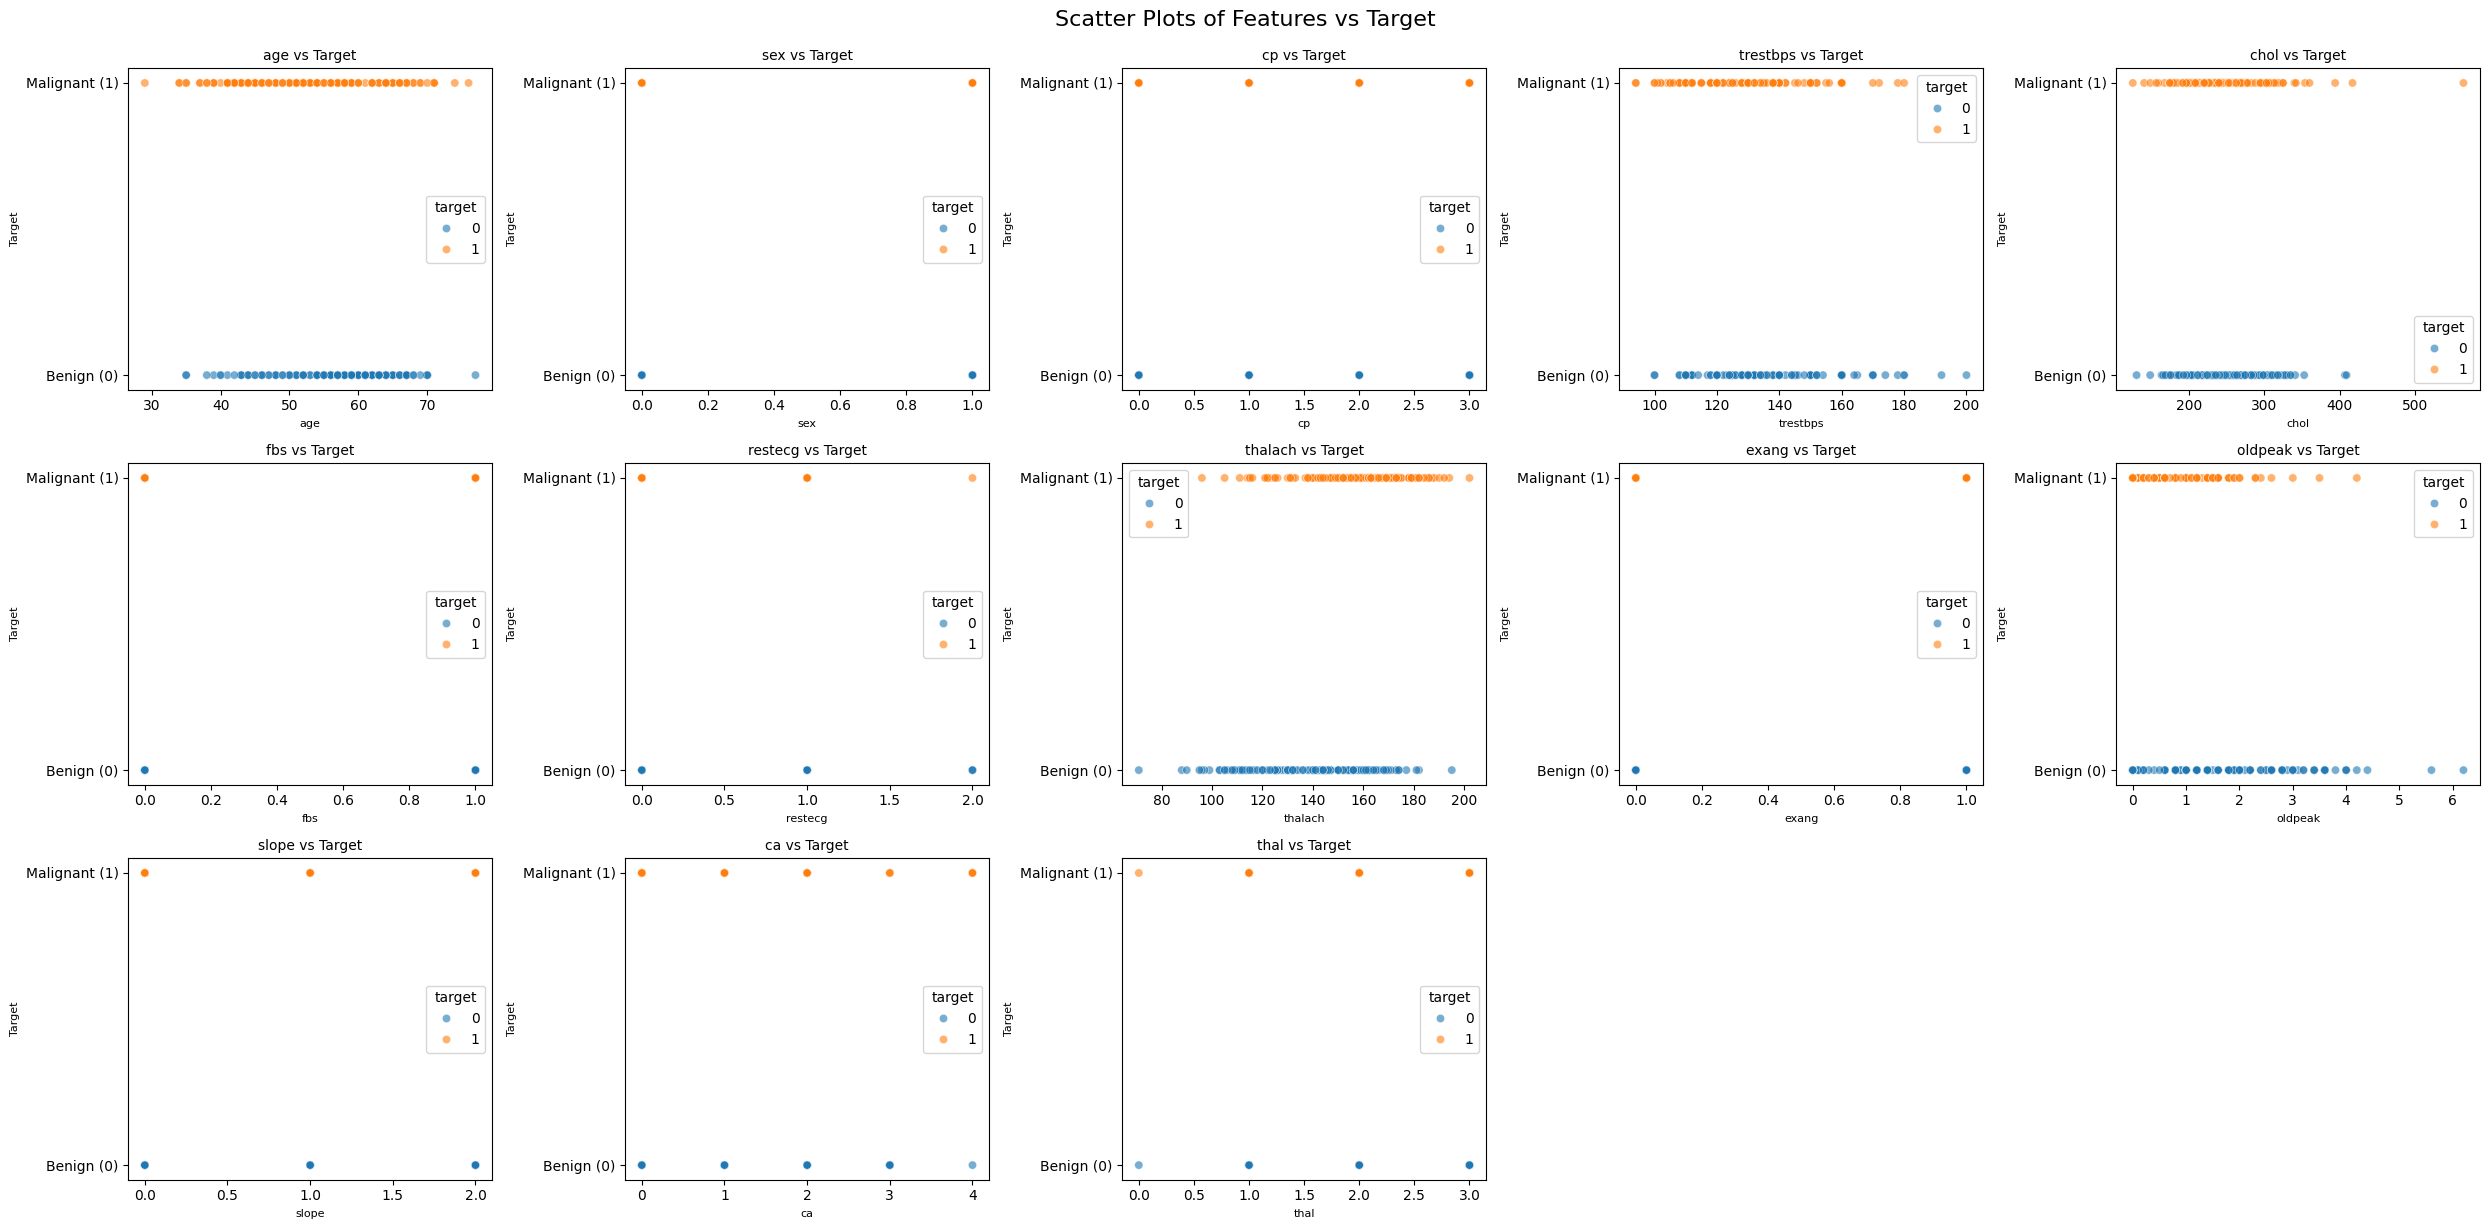

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming dataset is already defined from previous cells and contains 'target' column

# Get feature names from the 'dataset' DataFrame, excluding the 'target' column
feature_names = [col for col in dataset.columns if col != 'target']
n_features = len(feature_names)

# Determine grid size for subplots (e.g., 5 columns)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, feature_name in enumerate(feature_names):
    sns.scatterplot(x=dataset[feature_name], y=dataset['target'], hue=dataset['target'], ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{feature_name} vs Target', fontsize=10)
    axes[i].set_xlabel(feature_name, fontsize=8)
    axes[i].set_ylabel('Target', fontsize=8)
    axes[i].set_yticks([0, 1]) # Set y-ticks for binary target
    axes[i].set_yticklabels(['Benign (0)', 'Malignant (1)']) # Label y-ticks

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Scatter Plots of Features vs Target', y=1.02, fontsize=16)
plt.show()

In [6]:
import numpy as np
print("Null values in X:", np.isnan(X).sum())
print("Null values in y:", np.isnan(y).sum())

Null values in X: age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
Null values in y: 0


In [9]:
print(f"Data types of X:\n{X.dtypes}")
print(f"Are all columns in X numerical? {all(np.issubdtype(dtype, np.number) for dtype in X.dtypes)}")
print(f"Data type of y: {y.dtype}")
print(f"Is y fully numerical? {np.issubdtype(y.dtype, np.number)}")

Data types of X:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
dtype: object
Are all columns in X numerical? True
Data type of y: int64
Is y fully numerical? True


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.33,
                                                    random_state=44,
                                                    shuffle=True)

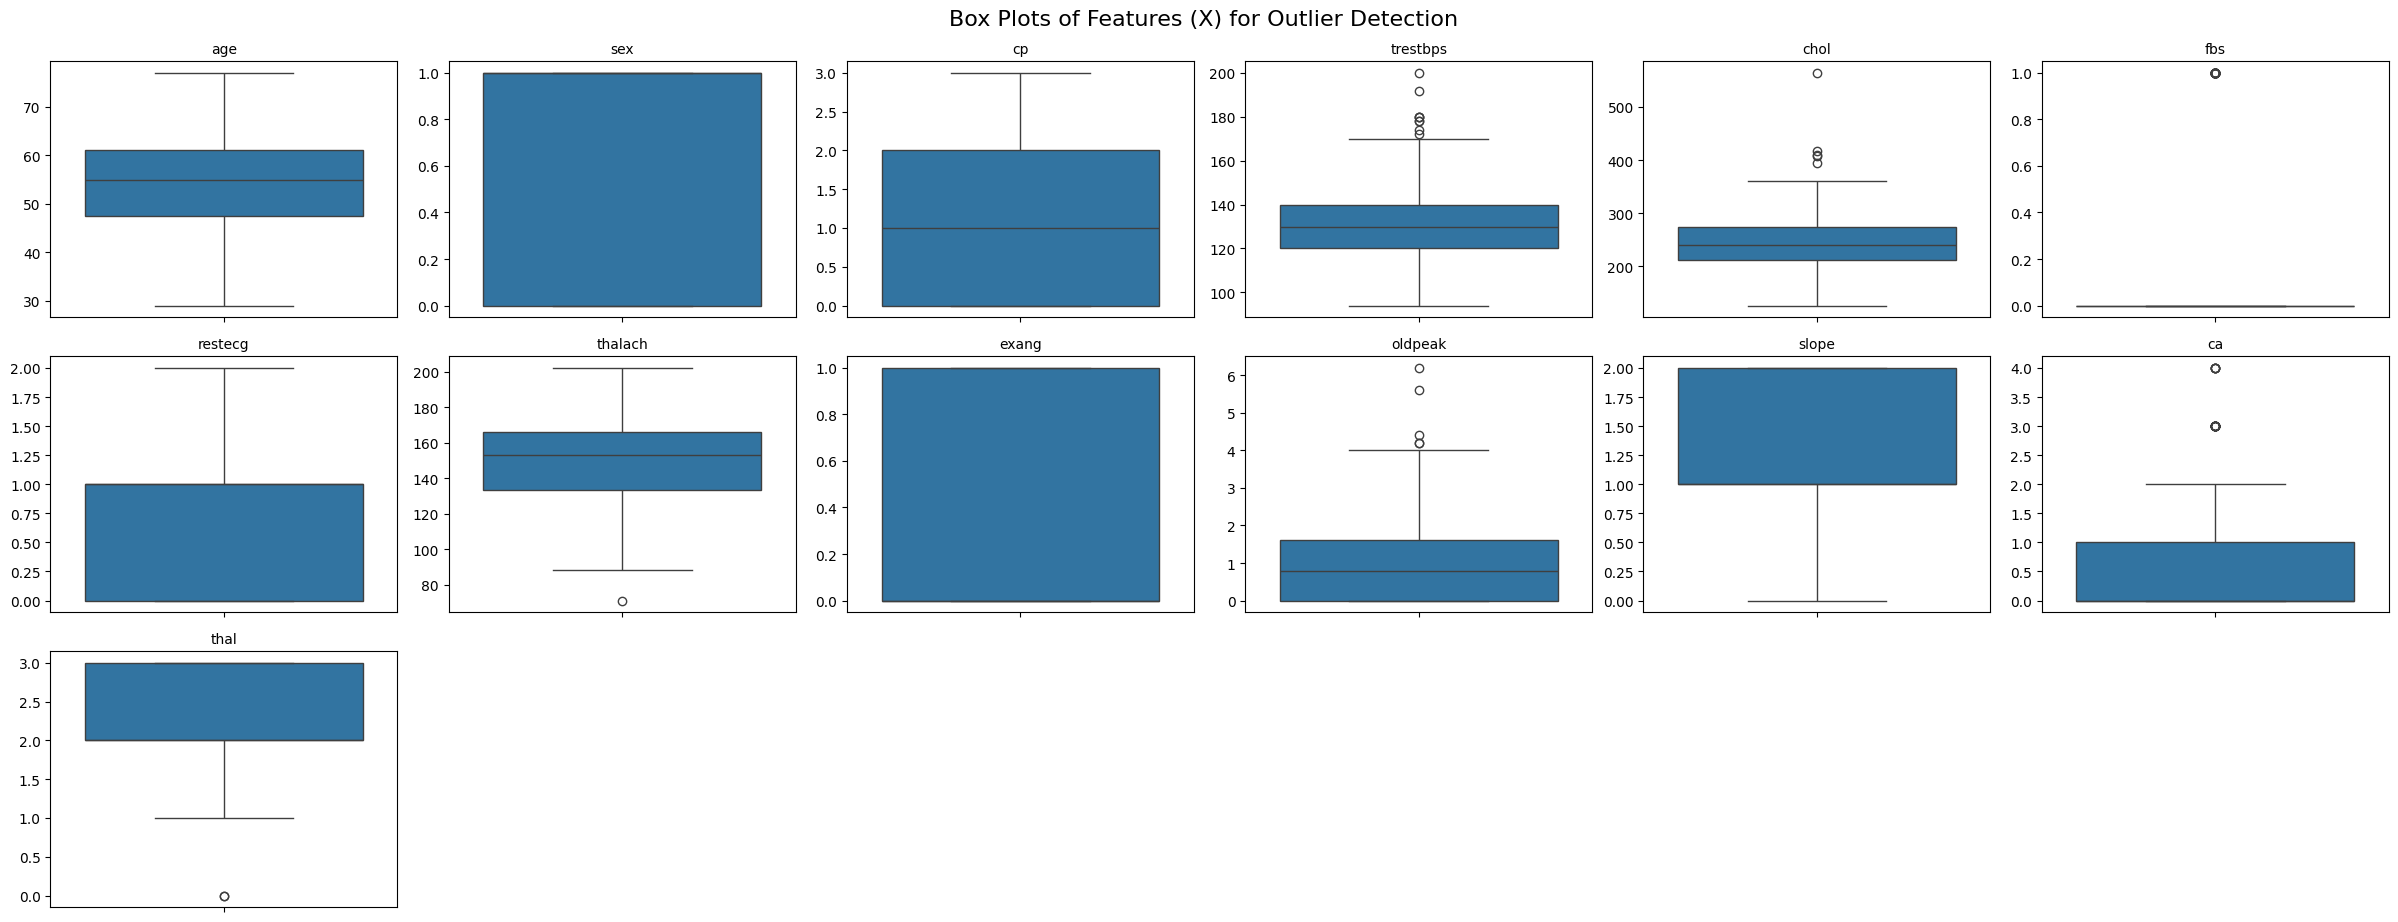

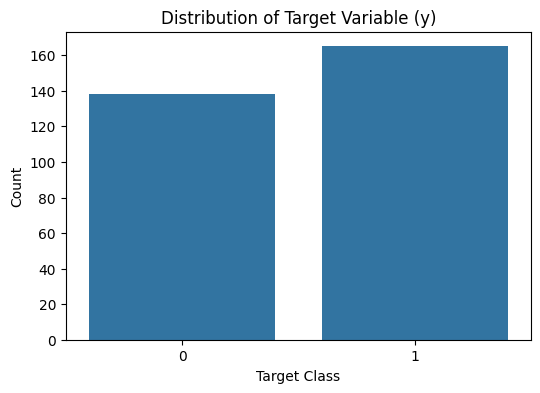

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
# No pandas import is needed if we're not creating df_X

# Use the existing feature_names variable
features = feature_names # 'feature_names' is already defined in the kernel state
n_features = len(features)

# Determine grid size for subplots (e.g., 6 columns)
n_cols = 6
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, feature_name in enumerate(features):
    # Plot directly from the X DataFrame using column name
    sns.boxplot(y=X[feature_name], ax=axes[i])
    axes[i].set_title(feature_name, fontsize=10) # Set title using feature_name
    axes[i].set_ylabel('') # Remove y-label to avoid clutter

# Remove any unused subplots if the number of features doesn't fill the grid perfectly
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Box Plots of Features (X) for Outlier Detection', y=1.02, fontsize=16)
plt.show()

# Visualize y distribution (since y is categorical, a count plot is more appropriate)
plt.figure(figsize=(6, 4))
sns.countplot(x=y) # Use y directly
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the training features (X_train)
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to the test features (X_test)
X_test_scaled = scaler.transform(X_test)


Applying IQR-based capping for outliers...
Outliers capped successfully in X_train_scaled and X_test_scaled.
Shape of X_train_scaled after capping: (203, 13)
Shape of X_test_scaled after capping: (100, 13)


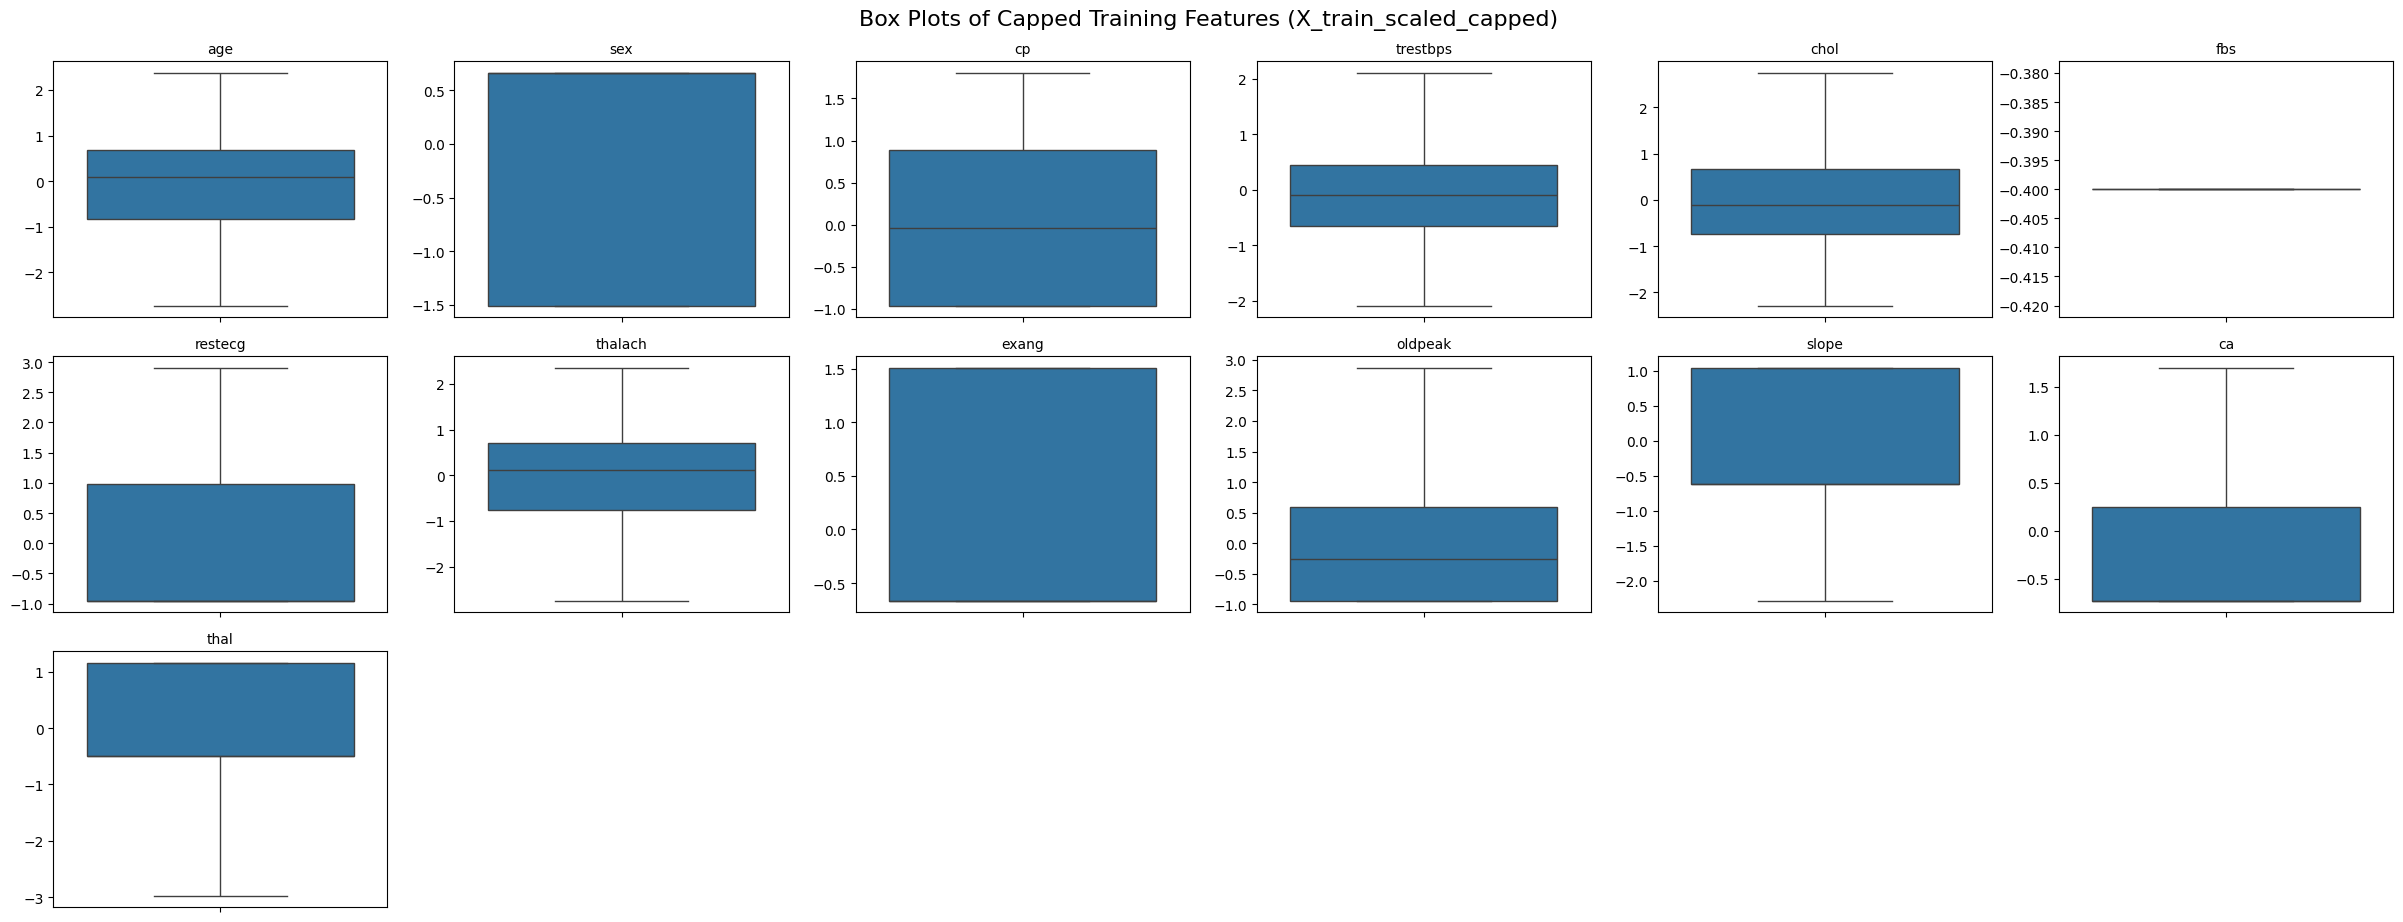

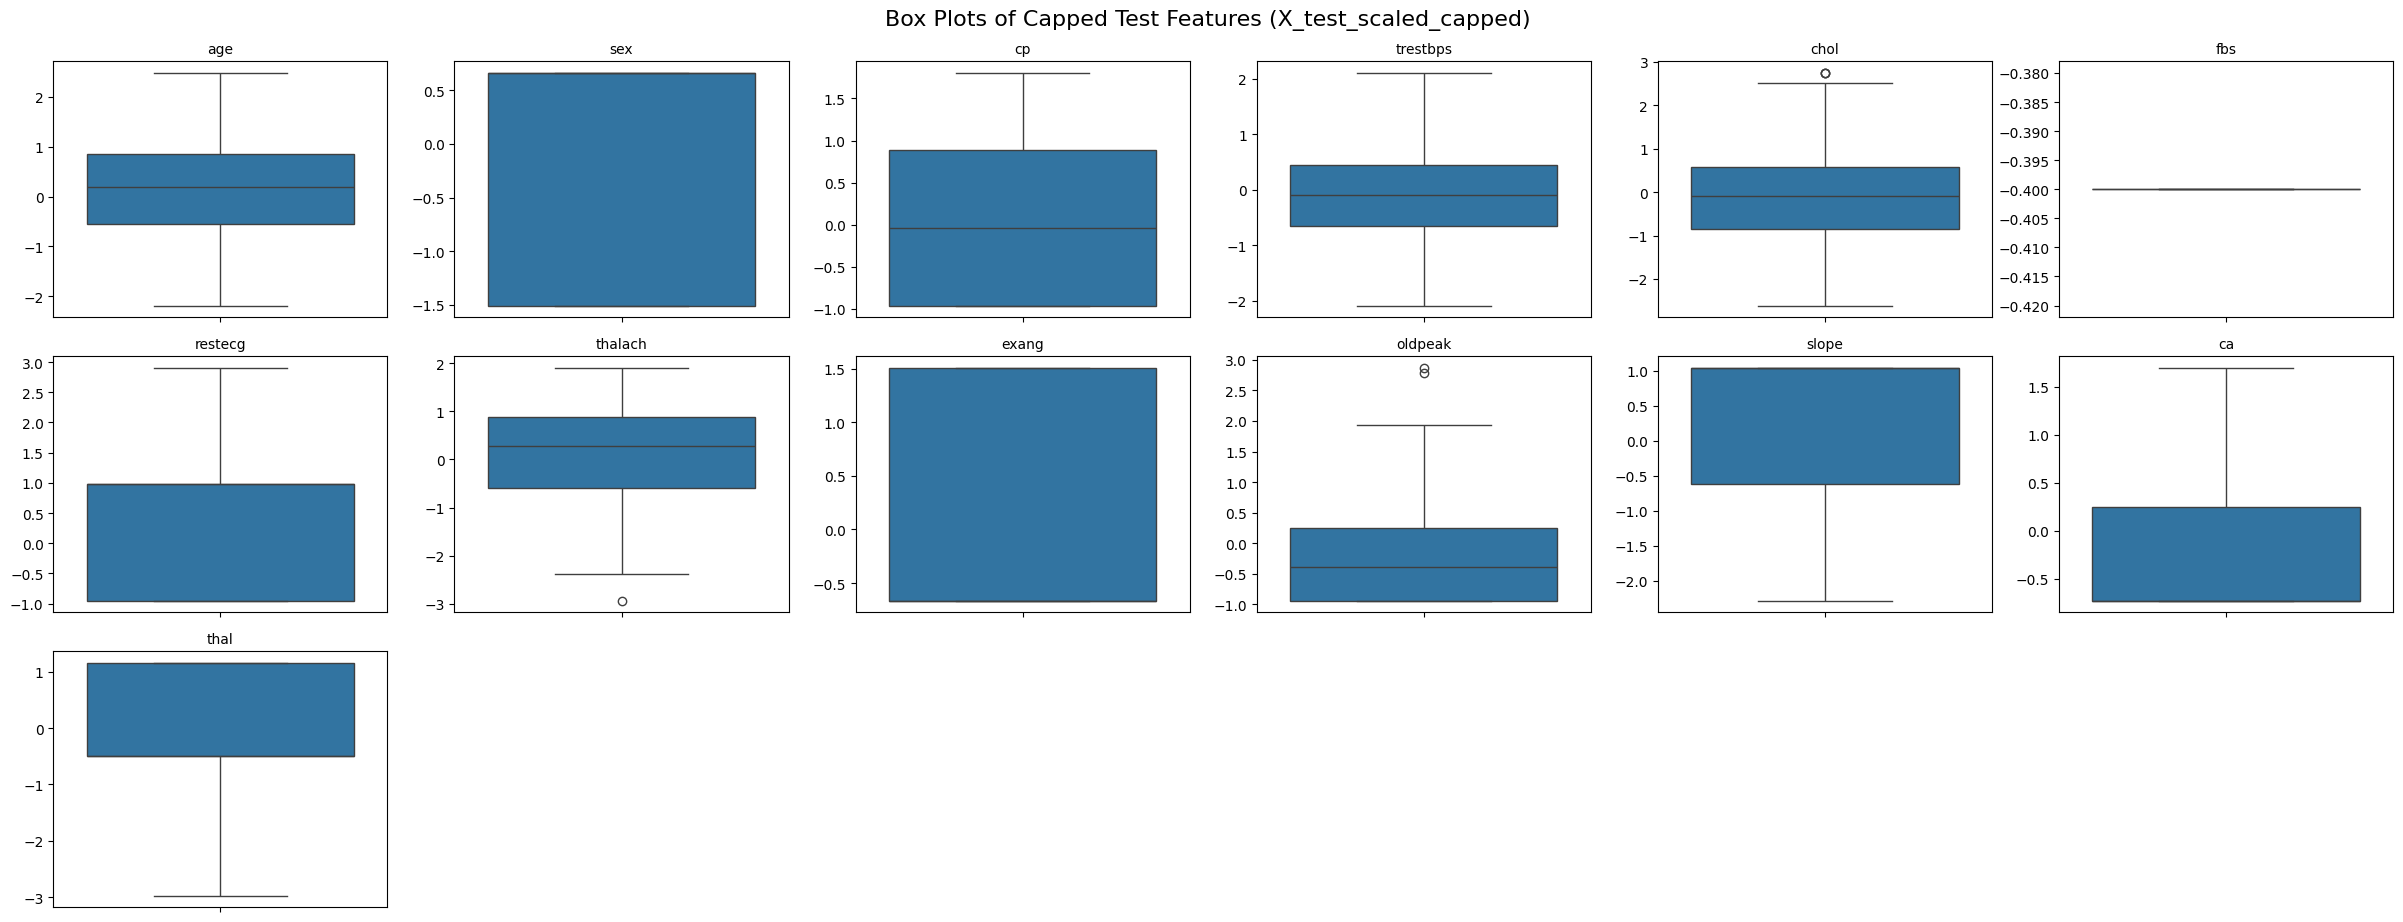

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# pandas is no longer needed for this cell as we're working directly with numpy arrays

# Create copies of the scaled NumPy arrays for capping
X_train_capped = X_train_scaled.copy()
X_test_capped = X_test_scaled.copy()

print("Applying IQR-based capping for outliers...")

# Use the existing 'features' variable for labeling plots
# 'features' is already defined in the kernel state from a previous cell
# feature_names = BreastData.feature_names # Original line causing error
n_features = len(features)

for i in range(n_features):
    # Calculate Q1, Q3, and IQR for each feature using np.percentile on the training data
    Q1 = np.percentile(X_train_capped[:, i], 25)
    Q3 = np.percentile(X_train_capped[:, i], 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping to training data (replace values outside bounds)
    X_train_capped[:, i] = np.where(X_train_capped[:, i] < lower_bound, lower_bound,
                                    np.where(X_train_capped[:, i] > upper_bound, upper_bound,
                                             X_train_capped[:, i]))

    # Apply capping to test data using bounds learned from training data
    X_test_capped[:, i] = np.where(X_test_capped[:, i] < lower_bound, lower_bound,
                                   np.where(X_test_capped[:, i] > upper_bound, upper_bound,
                                            X_test_capped[:, i]))

print("Outliers capped successfully in X_train_scaled and X_test_scaled.")

print(f"Shape of X_train_scaled after capping: {X_train_capped.shape}")
print(f"Shape of X_test_scaled after capping: {X_test_capped.shape}")

# --- Visualize the effect of capping with new box plots ---

n_cols = 6
n_rows = (n_features + n_cols - 1) // n_cols

# Plotting box plots for X_train_capped
fig_train_capped, axes_train_capped = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes_train_capped = axes_train_capped.flatten()

for i in range(n_features):
    sns.boxplot(y=X_train_capped[:, i], ax=axes_train_capped[i])
    axes_train_capped[i].set_title(features[i], fontsize=10) # Use 'features[i]' for title
    axes_train_capped[i].set_ylabel('')

# Remove any unused subplots
for j in range(n_features, len(axes_train_capped)):
    fig_train_capped.delaxes(axes_train_capped[j])

plt.tight_layout()
plt.suptitle('Box Plots of Capped Training Features (X_train_scaled_capped)', y=1.02, fontsize=16)
plt.show()

# Plotting box plots for X_test_capped
fig_test_capped, axes_test_capped = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes_test_capped = axes_test_capped.flatten()

for i in range(n_features):
    sns.boxplot(y=X_test_capped[:, i], ax=axes_test_capped[i])
    axes_test_capped[i].set_title(features[i], fontsize=10) # Use 'features[i]' for title
    axes_test_capped[i].set_ylabel('')

# Remove any unused subplots
for j in range(n_features, len(axes_test_capped)):
    fig_test_capped.delaxes(axes_test_capped[j])

plt.tight_layout()
plt.suptitle('Box Plots of Capped Test Features (X_test_scaled_capped)', y=1.02, fontsize=16)
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(penalty='l2',
                                         solver = 'sag',
                                         C=0.5,
                                         random_state=33,
                                         max_iter=1000,
                                         tol = 0.01)
logistic_regression.fit(X_train, y_train)

LogisticRegression(C=0.5, max_iter=1000, random_state=33, solver='sag',
                   tol=0.01)

In [21]:
y_pred = logistic_regression.predict(X_test)
y_pred_prob = logistic_regression.predict_proba(X_test)

print(y_pred_prob[:5])

[[0.26558354 0.73441646]
 [0.2505688  0.7494312 ]
 [0.22271603 0.77728397]
 [0.34103874 0.65896126]
 [0.31045714 0.68954286]]


In [22]:
print("train score:",logistic_regression.score(X_train, y_train))
print("test score: ",logistic_regression.score(X_test, y_test))
print("classes: ",logistic_regression.classes_)
print("no of iterations: ",logistic_regression.n_iter_)

train score: 0.7142857142857143
test score:  0.7
classes:  [0 1]
no of iterations:  [95]


[[27 19]
 [11 43]]


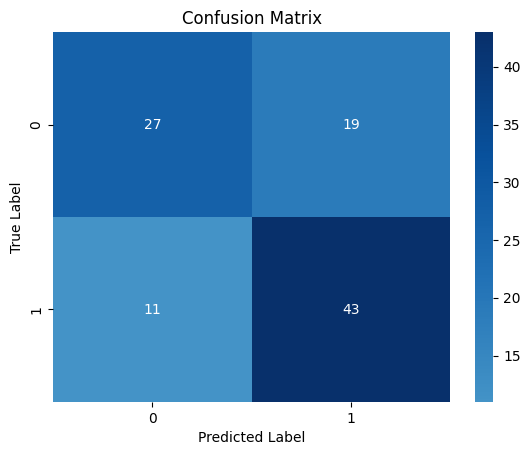

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
print(cm )
sns.heatmap(cm, center=True, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [28]:
from sklearn.metrics import classification_report

y_pred_train = logistic_regression.predict(X_train)

print("Classification Report for Training Set:")
print(classification_report(y_train, y_pred_train))

print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_pred))

Classification Report for Training Set:
              precision    recall  f1-score   support

           0       0.72      0.60      0.65        92
           1       0.71      0.81      0.76       111

    accuracy                           0.71       203
   macro avg       0.72      0.70      0.71       203
weighted avg       0.72      0.71      0.71       203


Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.71      0.59      0.64        46
           1       0.69      0.80      0.74        54

    accuracy                           0.70       100
   macro avg       0.70      0.69      0.69       100
weighted avg       0.70      0.70      0.70       100

